In [1]:
import sys
!{sys.executable} -m pip install playwright beautifulsoup4 pandas tqdm
!{sys.executable} -m playwright install firefox


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


🌐 Navigating to the Oscars database...
🎬 Setting filters via JavaScript...
🔍 Submitting search...
📸 Taking screenshot to verify results loaded...


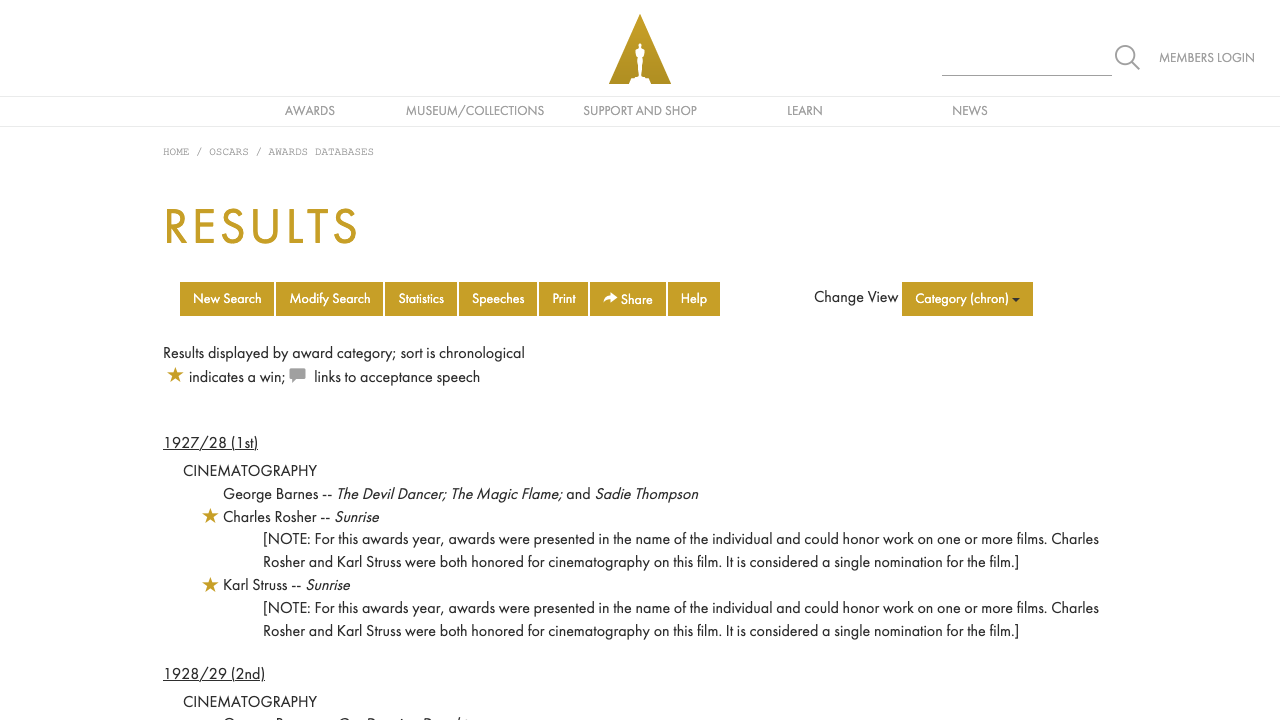

✅ Done! Check the screenshot above.


In [2]:
import asyncio
from playwright.async_api import async_playwright
from IPython.display import Image, display

async def load_results():
    global page, playwright_instance, browser

    playwright_instance = await async_playwright().start()
    browser = await playwright_instance.firefox.launch(headless=True)
    page = await browser.new_page()

    print("🌐 Navigating to the Oscars database...")
    await page.goto("https://awardsdatabase.oscars.org/", wait_until="networkidle")

    print("🎬 Setting filters via JavaScript...")
    await page.evaluate("""
        // Set Cinematography (value=8) on the category multiselect
        const catSelect = document.getElementById('BasicSearchView_AwardCategory');
        for (let opt of catSelect.options) {
            opt.selected = (opt.value === '8');
        }

        // Set Year From to 1 (1927/28 - 1st)
        const fromSelect = document.getElementById('BasicSearchView_AwardShowNumberFrom');
        fromSelect.value = '1';

        // Set Year To to 97 (2024 - 97th)
        const toSelect = document.getElementById('BasicSearchView_AwardShowNumberTo');
        toSelect.value = '97';
    """)

    print("🔍 Submitting search...")
    await page.evaluate("""
        document.getElementById('submitvalue') && 
            (document.getElementById('submitvalue').value = 'Basic');
    """)
    await page.click("#btnbasicsearch")
    await page.wait_for_load_state("networkidle")

    print("📸 Taking screenshot to verify results loaded...")
    screenshot = await page.screenshot()
    display(Image(screenshot))

    print("✅ Done! Check the screenshot above.")

await load_results()


📜 Scrolling to load all results...
  Scroll 1: page height 24787 → 24787
  ✅ No more new content — we've reached the bottom!


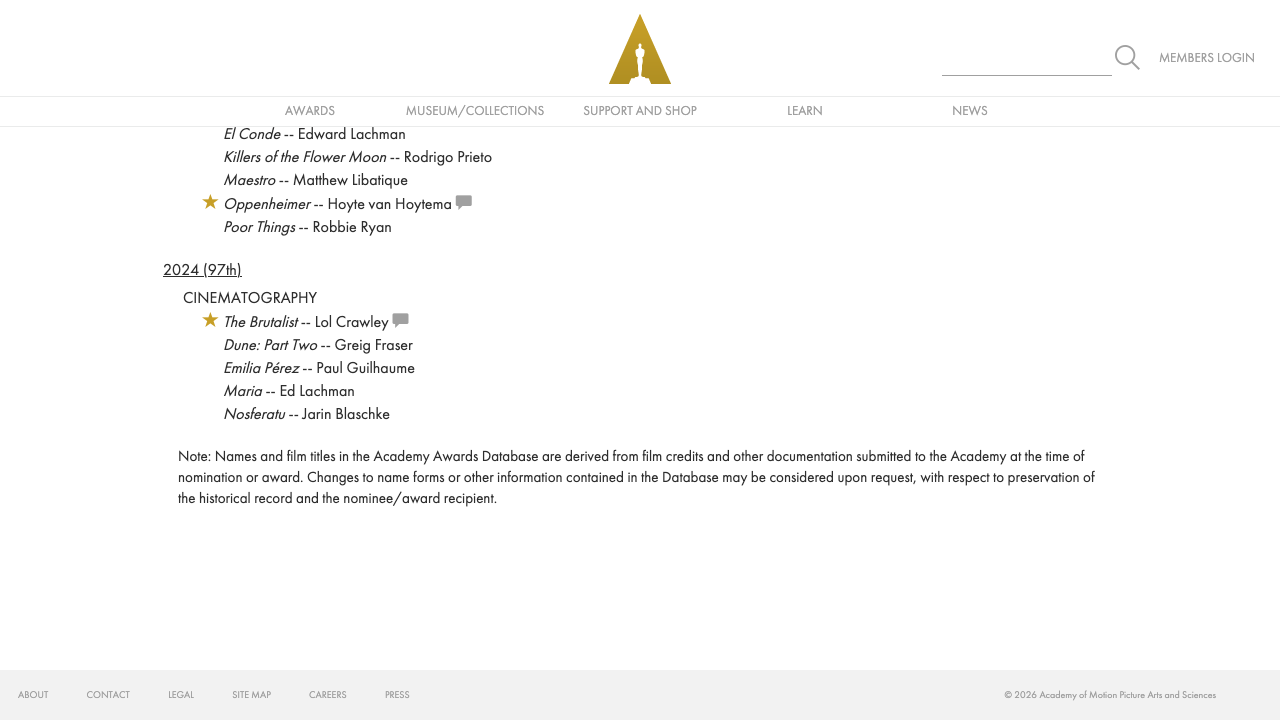

📸 Screenshot taken — check that results go all the way to the 1st ceremony.


In [3]:
import asyncio
from IPython.display import Image, display

async def scroll_to_bottom():
    print("📜 Scrolling to load all results...")
    last_height = await page.evaluate("document.body.scrollHeight")
    iterations = 0

    while True:
        # Scroll to the bottom
        await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
        await page.wait_for_timeout(1500)  # wait for new content to load

        new_height = await page.evaluate("document.body.scrollHeight")
        iterations += 1
        print(f"  Scroll {iterations}: page height {last_height} → {new_height}")

        if new_height == last_height:
            print("  ✅ No more new content — we've reached the bottom!")
            break
        last_height = new_height

    # Take a final screenshot to confirm
    screenshot = await page.screenshot()
    display(Image(screenshot))
    print("📸 Screenshot taken — check that results go all the way to the 1st ceremony.")

await scroll_to_bottom()

In [4]:
from bs4 import BeautifulSoup
import pandas as pd

print("🔍 Grabbing page source...")
html = await page.content()
soup = BeautifulSoup(html, "html.parser")

print("🎬 Parsing nominations...")
rows = []

# Each year is a "result-group"
for group in soup.select("div.result-group"):
    year_tag = group.select_one("div.result-group-title a")
    year = year_tag.text.strip() if year_tag else "Unknown"

    # Each nomination is a "result-details" div
    for item in group.select("div.result-details"):
        film_tag = item.select_one("div.awards-result-film-title a")
        nominee_tag = item.select_one("div.awards-result-nominationstatement a")
        winner = item.select_one("span.glyphicon-star") is not None

        film = film_tag.text.strip() if film_tag else "Unknown"
        nominee = nominee_tag.text.strip() if nominee_tag else "Unknown"

        rows.append({
            "Year": year,
            "Film": film,
            "Nominee": nominee,
            "Winner": winner
        })

df = pd.DataFrame(rows)
print(f"✅ Scraped {len(df)} nominations!")
print()
df.head(10)

🔍 Grabbing page source...
🎬 Parsing nominations...
✅ Scraped 642 nominations!



,Year,Film,Nominee,Winner
0,1927/28 (1st),The Devil Dancer;,George Barnes,False
1,1927/28 (1st),Sunrise,Charles Rosher,True
2,1927/28 (1st),Sunrise,Karl Struss,True
3,1928/29 (2nd),Our Dancing Daughters,George Barnes,False
4,1928/29 (2nd),White Shadows in the South Seas,Clyde De Vinna,True
5,1928/29 (2nd),In Old Arizona,Arthur Edeson,False
6,1928/29 (2nd),Four Devils;,Ernest Palmer,False
7,1928/29 (2nd),The Divine Lady,John Seitz,False
8,1929/30 (3rd),All Quiet on the Western Front,(Arthur Edeson),False
9,1929/30 (3rd),Anna Christie,(William Daniels),False


In [5]:
df["Gender"] = "Man"
women = ["Rachel Morrison", "Ari Wegner", "Mandy Walker"]
df.loc[df["Nominee"].isin(women), "Gender"] = "Woman"
df

,Year,Film,Nominee,Winner,Gender
0,1927/28 (1st),The Devil Dancer;,George Barnes,False,Man
1,1927/28 (1st),Sunrise,Charles Rosher,True,Man
2,1927/28 (1st),Sunrise,Karl Struss,True,Man
3,1928/29 (2nd),Our Dancing Daughters,George Barnes,False,Man
4,1928/29 (2nd),White Shadows in the South Seas,Clyde De Vinna,True,Man
...,...,...,...,...,...
637,2024 (97th),The Brutalist,Lol Crawley,True,Man
638,2024 (97th),Dune: Part Two,Greig Fraser,False,Man
639,2024 (97th),Emilia Pérez,Paul Guilhaume,False,Man
640,2024 (97th),Maria,Ed Lachman,False,Man


In [ ]:
df[df["Gender"] == "Woman"] # Checking if the assignment worked

,Year,Film,Nominee,Winner,Gender
605,2017 (90th),Mudbound,Rachel Morrison,False,Woman
624,2021 (94th),The Power of the Dog,Ari Wegner,False,Woman
629,2022 (95th),Elvis,Mandy Walker,False,Woman


In [7]:
# Adding 2025 (98th) nominees
new_rows = pd.DataFrame([
    {"Year": "2025 (98th)", "Film": "Sinners",                "Nominee": "Autumn Durald Arkapaw", "Winner": True,  "Gender": "Woman"},
    {"Year": "2025 (98th)", "Film": "Frankenstein",           "Nominee": "Dan Laustsen",          "Winner": False, "Gender": "Man"},
    {"Year": "2025 (98th)", "Film": "Marty Supreme",          "Nominee": "Darius Khondji",        "Winner": False, "Gender": "Man"},
    {"Year": "2025 (98th)", "Film": "One Battle After Another","Nominee": "Michael Bauman",       "Winner": False, "Gender": "Man"},
    {"Year": "2025 (98th)", "Film": "Train Dreams",           "Nominee": "Adolpho Veloso",        "Winner": False, "Gender": "Man"},
])

df = pd.concat([df, new_rows], ignore_index=True)
df

,Year,Film,Nominee,Winner,Gender
0,1927/28 (1st),The Devil Dancer;,George Barnes,False,Man
1,1927/28 (1st),Sunrise,Charles Rosher,True,Man
2,1927/28 (1st),Sunrise,Karl Struss,True,Man
3,1928/29 (2nd),Our Dancing Daughters,George Barnes,False,Man
4,1928/29 (2nd),White Shadows in the South Seas,Clyde De Vinna,True,Man
...,...,...,...,...,...
642,2025 (98th),Sinners,Autumn Durald Arkapaw,True,Woman
643,2025 (98th),Frankenstein,Dan Laustsen,False,Man
644,2025 (98th),Marty Supreme,Darius Khondji,False,Man
645,2025 (98th),One Battle After Another,Michael Bauman,False,Man


In [8]:
df.to_csv("oscars_cinematography.csv", index=False)